# Exercise: Conformers and potential-energy surfaces

In this exercise we will be relaxing alanine dipeptide conformers using the AIMNet2 MLIP. Alanine dipeptide is a standard benchmark used in computational chemistry and molecular dynamics to study protein folding and conformational dynamics. This is because it exhibits multiple stable, low-energy states.

We provide a set of 100 conformers generated using the RDKit python package (see demo_tools/generate_adp_conformers.py for details on how we did this). You will optimize the conformers using AIMNet2, along with generate a 2D potential energy surface for the system. 

![Alanine dipeptide](alanine_dipeptide.png)

**Kernel:** AIMNet2. Run cells in order from a fresh kernel.

**Learning goals:** relate conformers to torsional minima; distinguish rigid and relaxed scans;
use independent scan rows as a parallel workload. Start with the coarse live scan. Use supplied
reference results for the dense 2D relaxed surface.

**Predict:** can two different starting conformers relax to the same minimum? Will a rigid torsional
scan generally have higher energies than a relaxed scan at the same angles?


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
sys.path.insert(0,str(Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read, write
from ase.visualize import view

from demo_tools.geometry_utils import align_atoms_list, signed_angle, deduplicate_conformers
from demo_tools.helpers import start_exercise

_, OUTPUT = start_exercise()


Python: /home/nchopper/anaconda3/envs/aimnet2/bin/python
Inputs: /home/nchopper/mlip-demo/workshop_demo/ConformerSampling
New results: /home/nchopper/mlip-demo/workshop_demo/ConformerSampling/results/20260923-162839-e51167


## 1. Load structures and initialize the calculator
The supplied XYZ contains multiple conformers of the same molecule. These are pre-optimized with an MMFF forcefield.

Each copy needs a calculator before energy or force evaluation. Charge is zero for this neutral molecule.


In [4]:
mols = read('./alanine_dipeptide_conformers.xyz', index=':')
view(mols[0], viewer='x3d')


## 2. Identify the two torsions
Atom indices are zero-based. A torsion is defined by four atoms; the rotation list identifies which
part of the molecule moves. These lists are specific to the supplied atom ordering, not arbitrary XYZ files.
ASE reports dihedrals in [0, 360); plots below wrap them into [-180, 180).
Print the atom indices and elements to connect these lists to the structure.


In [5]:
phi_indices = [6, 4, 3, 1]
phi_rotation_indices = [13, 0, 1, 2, 10, 11, 12]
psi_indices = [3, 4, 6, 8]
psi_rotation_indices = [7, 8, 9, 18, 19, 20, 21]
print('Initial (phi, psi):', f'{signed_angle(mols[0].get_dihedral(*phi_indices)):.1f},',
      f'{signed_angle(mols[0].get_dihedral(*psi_indices)):.1f}')


Initial (phi, psi): -149.6, 37.2


## 3.  Get initial distribution of torsion angles

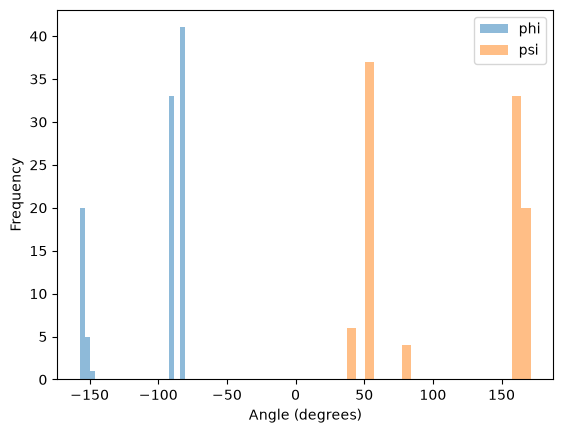

In [6]:
psis = []
phis = []
for mol in mols:
    phis.append(signed_angle(mol.get_dihedral(*phi_indices)))
    psis.append(signed_angle(mol.get_dihedral(*psi_indices)))

import matplotlib.pyplot as plt
plt.hist(phis, bins=20, alpha=0.5, label='phi')
plt.hist(psis, bins=20, alpha=0.5, label='psi')
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Stack all atoms objects into one and view 
central_cccn = [3,4,5,6]
aligned_mols = align_atoms_list(
    geometries=mols,
    atom_indices=central_cccn,
    reference_index=0
)
combined_mols = aligned_mols[0].copy()
for mol in aligned_mols[1:]:
    combined_mols.extend(mol)
view(combined_mols,viewer="x3d")


# 3.  Deduplicate conformers

Our next step is to optimize these conformers with AIMNet2.  Before we do that, we should remove any structures that are nearly identical.

In [9]:
# Deduplicate the conformers to remove near-duplicate structures based on RMSD
# The RMSD threshold is set very low to ensure only nearly identical conformers are removed.
# The heavy_atoms_only flag ensures that only non-hydrogen atoms are considered for RMSD comparison.

uniq_confs = deduplicate_conformers(mols, rmsd_threshold=0.001, heavy_atoms_only=True)

In [ ]:
central_cccn = [3,4,5,6]
aligned_mols = align_atoms_list(
    geometries=uniq_confs,
    atom_indices=central_cccn,
    reference_index=0
)
combined_mols = aligned_mols[0].copy()
for mol in aligned_mols[1:]:
    combined_mols.extend(mol)
view(combined_mols,viewer="x3d")

## 3. Relax conformers
The reported energy is a potential energy, not a free energy or a population


In [10]:
import os
os.environ['TORCH_COMPILE_DISABLE'] = '1'
from aimnet.calculators import AIMNet2ASE
from ase.optimize import BFGS


calculator = AIMNet2ASE('aimnet2', charge=0)

opt_mols = []
relaxation_trajectory = []
for i, original in enumerate(uniq_confs):
    mol = original.copy()
    mol.calc = calculator
    opt = BFGS(mol)

    trajectory = []
    def record_dihedrals():
        trajectory.append((
            signed_angle(mol.get_dihedral(*phi_indices)),
            signed_angle(mol.get_dihedral(*psi_indices)),
        ))

    opt.attach(record_dihedrals, interval=1)
    opt.run(fmax=0.05)


    opt_mols.append(mol)
    relaxation_trajectory.append(trajectory)
    print(i, mol.get_potential_energy(), 'eV')
write(OUTPUT / 'relaxed_conformers.extxyz', opt_mols)
view(opt_mols[0], viewer='x3d')


Warp CUDA warning: Could not find or load the NVIDIA CUDA driver. GPU execution will not be available.


      Step     Time          Energy          fmax
BFGS:    0 15:30:24   -13501.948574        1.334328
BFGS:    1 15:30:24   -13501.994706        1.279382
BFGS:    2 15:30:24   -13502.020679        0.527134
BFGS:    3 15:30:24   -13502.034117        0.189906
BFGS:    4 15:30:25   -13502.039010        0.170434
BFGS:    5 15:30:25   -13502.044254        0.192045
BFGS:    6 15:30:25   -13502.048182        0.187092
BFGS:    7 15:30:25   -13502.050695        0.155550
BFGS:    8 15:30:26   -13502.052375        0.142230
BFGS:    9 15:30:26   -13502.054231        0.137553
BFGS:   10 15:30:26   -13502.057035        0.118346
BFGS:   11 15:30:26   -13502.058737        0.075427
BFGS:   12 15:30:26   -13502.059673        0.065645
BFGS:   13 15:30:27   -13502.060284        0.059453
BFGS:   14 15:30:27   -13502.061137        0.064907
BFGS:   15 15:30:27   -13502.061924        0.057011
BFGS:   16 15:30:27   -13502.062452        0.040793
0 -13502.06245182753 eV
      Step     Time          Energy       

## 4. Make a coarse rigid scan
Only the torsions change. No geometry optimizations are performed, just energy evaluations. Each grid point starts from
the same initial geometry. The default 30-degree grid has 144 points; 10 degrees has 1296 points.
We omit the duplicate +180 endpoint because torsion angles are periodic.
High-energy regions can contain close contacts. Treat them as candidates for inspection, not reliable chemistry.


Completed phi=-180 degrees
Completed phi=-150 degrees
Completed phi=-120 degrees
Completed phi=-90 degrees
Completed phi=-60 degrees
Completed phi=-30 degrees
Completed phi=0 degrees
Completed phi=30 degrees
Completed phi=60 degrees
Completed phi=90 degrees
Completed phi=120 degrees
Completed phi=150 degrees
Completed phi=180 degrees


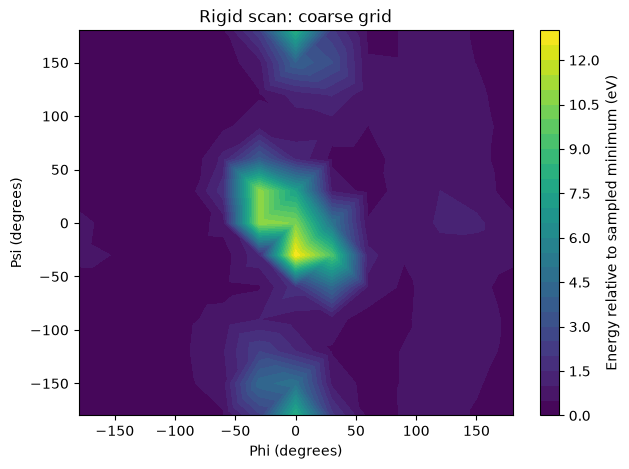

In [12]:
STEP = 30
angles = np.arange(-180, 181, STEP)
rigid_data = []
for phi in angles:
    for psi in angles:
        mol = mols[0].copy()
        mol.set_dihedral(*phi_indices, float(phi), indices=phi_rotation_indices)
        mol.set_dihedral(*psi_indices, float(psi), indices=psi_rotation_indices)
        mol.calc = calculator
        rigid_data.append((phi, psi, mol.get_potential_energy()))
    print(f'Completed phi={phi} degrees')
rigid_data = np.array(rigid_data)
np.savetxt(OUTPUT / 'rigid_scan.csv', rigid_data, delimiter=',',
           header='phi_deg,psi_deg,energy_eV', comments='')
plt.figure(figsize=(7, 5))
plt.tricontourf(rigid_data[:, 0], rigid_data[:, 1], rigid_data[:, 2]-rigid_data[:, 2].min(), levels=30)
plt.xlabel('Phi (degrees)'); plt.ylabel('Psi (degrees)')
plt.colorbar(label='Energy relative to sampled minimum (eV)')
plt.title('Rigid scan: coarse grid'); plt.show()


## 5. Prepare a relaxed row for a batch scan
Hold psi at -180 degrees and step through phi. Reusing the preceding relaxed structure can help
convergence but can also follow one local branch of the surface. It does not guarantee a global minimum.

This section creates the input for the parallel extension. If time is short, skip to section 7 and
use the supplied reference surface. A failed relaxation stops row preparation rather than silently
passing an unconverged input to the batch job.


In [ ]:
# Define our calculator
calculator = AIMNet2ASE('aimnet2', 
                  charge=0,
                  )

# Import necessary modules for constraints and optimization
from ase.constraints import FixInternals
from ase.optimize import BFGS
from ase.io import write

# Prepare the initial relaxed scan molecule by copying one of our conformers and setting the dihedrals
relaxed_scan_mol = mols[0].copy()
relaxed_scan_mol.set_dihedral(*phi_indices, -190, indices= phi_rotation_indices)
relaxed_scan_mol.set_dihedral(*psi_indices, -180, indices= psi_rotation_indices)

# Get relaxed phi structures from -180 to 180 degrees, holding psi at -180
phi_1D_scan_structures = []
phi_1d_struct = relaxed_scan_mol.copy()
for i,phi in enumerate(range(-180, 181, 10)):
    # Remove any constraints on the Atoms object
    phi_1d_struct.set_constraint()

    # Attach the calculator to the Atoms object
    phi_1d_struct.calc = calculator

    # Rotate the phi dihedral by 10 degrees
    phi_1d_struct.rotate_dihedral(*phi_indices, 10, indices= phi_rotation_indices)

    # Apply constraints to the dihedrals
    phi_1d_struct.set_constraint(FixInternals(dihedrals_deg=[(phi, phi_indices), (-180, psi_indices)]))

    # Optimize
    dyn = BFGS(phi_1d_struct)
    dyn.run(fmax=0.01)

    # Store the relaxed structure and its associated data
    phi_1d_struct.info['target_phi'] = phi
    phi_1d_struct.info['target_psi'] = -180
    phi_1d_struct.info['actual_phi'] = phi_1d_struct.get_dihedral(*phi_indices)
    phi_1d_struct.info['actual_psi'] = phi_1d_struct.get_dihedral(*psi_indices)
    phi_1d_struct.info['Energy'] = phi_1d_struct.get_potential_energy()
    phi_1D_scan_structures.append(phi_1d_struct.copy())

# Write the relaxed phi scan structures to an EXTXYZ file
write(phi_1D_scan_structures, 'phi_1D_scan_structures.xyz', format='extxyz')

## 6. Optional HPRC extension: parallelize independent rows
Each phi row scans psi sequentially. Rows can run independently, but points within a row depend
on the previous relaxation. This is why distributing rows is a useful parallelization strategy.

From a terminal in this folder, activate AIMNet2 in your allocated compute environment and run:

```bash
python parallel_relaxed_scan.py --input results/YOUR_RUN/phi_1D_scan_structures.xyz --output results/YOUR_RUN/Relaxed_2D_scan.xyz --workers 4 --step 30
```

Replace `YOUR_RUN` with the directory printed above. Four workers require four allocated CPUs.
For Slurm, adapt `submit_scan.slurm` to the site's environment activation, then use
`sbatch submit_scan.slurm INPUT_PATH OUTPUT_PATH`. The script also writes completed rows alongside
the output so a failed job does not discard every completed row. See the README for recovery.

**Discuss:** why might four workers take more than one quarter of the serial time? Each process
loads its own model, so memory and startup costs matter too.


## 7. Inspect a relaxed surface

The default below reads supplied results. 

If you ran (5) and (6), you need to supply the path to your output data (if you copied the example execution in 6 then that path is './results/YOUR_RUN/Relaxed_2D_scan.xyz')

Compare the relaxed scan PES to the rigid scan PES.


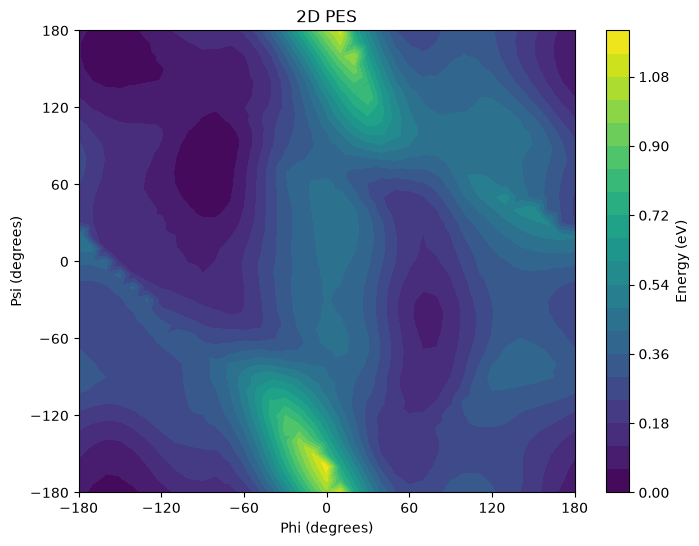

In [13]:
PATH_TO_DATA = './reference_results/Relaxed_2D_scan.xyz'
structures = read(PATH_TO_DATA, index=':')
phis = []
psis = []
es = []
for structure in structures:
    phis.append(structure.info["target_phi"])
    psis.append(structure.info["target_psi"])
    es.append(structure.info["Energy"])


relaxed_scan_data = np.array(list(zip(phis, psis, es)))
phi = relaxed_scan_data[:,0]
psi = relaxed_scan_data[:,1]
energy = relaxed_scan_data[:,2] - np.min(relaxed_scan_data[:,2])

# Create a 2D potential energy surface plot
plt.figure(figsize=(8,6))
plt.tricontourf(phi, psi, energy, levels=20, cmap='viridis')
plt.colorbar(label='Energy (eV)')
plt.xlabel('Phi (degrees)')
plt.ylabel('Psi (degrees)')
plt.title('2D PES')

plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xticks(np.arange(-180, 181, 60))
plt.yticks(np.arange(-180, 181, 60))
plt.show()

(-180.0, 180.0)

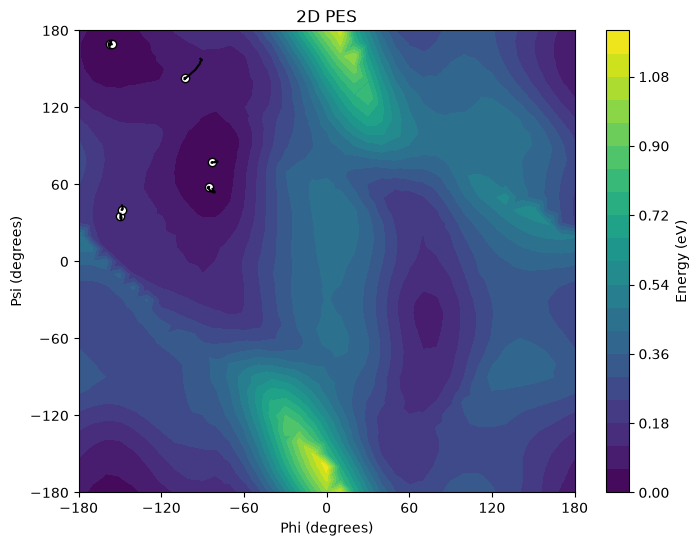

In [14]:
# Let's add our optimized structures to this to see where they converged to.
plt.figure(figsize=(8,6))
plt.tricontourf(phi, psi, energy, levels=20, cmap='viridis')
plt.colorbar(label='Energy (eV)')
plt.xlabel('Phi (degrees)')
plt.ylabel('Psi (degrees)')
plt.title('2D PES')

plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xticks(np.arange(-180, 181, 60))
plt.yticks(np.arange(-180, 181, 60))
# plt.show()

for mol, traj in zip(opt_mols, relaxation_trajectory):
    plt.scatter(signed_angle(mol.get_dihedral(*phi_indices)),
                signed_angle(mol.get_dihedral(*psi_indices)), c='white', edgecolors='black')
    plt.plot([phi for phi, psi in traj], [psi for phi, psi in traj], c='black')
plt.xlim(-180,180)
plt.ylim(-180,180)

## Try, explain, and report
- Do relaxed conformers lie near low-energy regions of the relaxed surface?
- Compare rigid and relaxed scans. Their separately shifted color scales do not show absolute energy differences.
- Reverse the scan direction as an extension. Does continuation follow a different local minimum?

**Checkpoint:** report grid spacing, convergence threshold, whether data were supplied or calculated,
and one physical conclusion plus one limitation. Save the model identifier with any results you share.
